In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

transactions = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-1/transactions_clean.parquet')
customers = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-1/customers_clean.parquet')
articles = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-1/articles_clean.parquet')

print(f"Transactions: {transactions.shape}")
print(f"Customers: {customers.shape}")
print(f"Articles: {articles.shape}")

# Make sure date column is parsed
# transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

Transactions: (2296723, 5)
Customers: (100000, 8)
Articles: (81940, 25)


In [3]:
REFERENCE_DATE = pd.to_datetime('2020-09-22')

rfm = transactions.groupby('customer_id').agg(
    last_purchase_date=('t_dat', 'max'),
    frequency=('article_id', 'count'),
    monetary=('price', 'sum')
).reset_index()

# Recency = how many days ago was their last purchase
rfm['recency'] = (REFERENCE_DATE - rfm['last_purchase_date']).dt.days

# Average order value
rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

print(rfm.describe())
print(rfm.head())

                  last_purchase_date     frequency      monetary  \
count                          99345  99345.000000  99345.000000   
mean   2020-01-30 11:22:56.620866816     23.118657      0.642878   
min              2018-09-20 00:00:00      1.000000      0.000847   
25%              2019-08-21 00:00:00      3.000000      0.088034   
50%              2020-04-23 00:00:00      9.000000      0.244356   
75%              2020-08-05 00:00:00     27.000000      0.698000   
max              2020-09-22 00:00:00   1237.000000     41.327051   
std                              NaN     38.071822      1.159773   

            recency  avg_order_value  
count  99345.000000     99345.000000  
mean     235.525734         0.028739  
min        0.000000         0.000847  
25%       48.000000         0.020962  
50%      152.000000         0.026122  
75%      398.000000         0.033316  
max      733.000000         0.422034  
std      221.089387         0.014270  
                                    

In [4]:
# Score each dimension into quintiles 1 to 5
# For recency, lower days = better = higher score, so we reverse it
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Composite RFM score
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score']].head(10))

                                         customer_id  recency  frequency  \
0  0000ffa57a8098a6cd99c0f0782b3e674f47d68db69dc1...      299          3   
1  00018385675844f7a6babbed41b5655b5727fb16483b6e...      324          9   
2  0002e4924f38a599994d83110e5db96d62bbffce7fea85...      468          2   
3  00036ffb474cd9818bd0d9045fd5863b0167aabae75e61...      322         25   
4  000383021a8cf9a542b9c855b42f99aa76374873661e83...      693          5   
5  0003c98542d16e740156638a7d133d93360d3ff3d0b7ec...      669          2   
6  000538c14c490fee547e2703439f70bdb8748e2a62f875...       88         30   
7  000563485cbb7850b0a93c6606f89c5b961c6647d1bd48...      110         17   
8  0006d1fc72f81261e70e74249ab2c348e21a093ba40f2a...       81         53   
9  0008daf19b2a7cd6fa00836c717aa0f143c83d88c35e02...        3          1   

   monetary  R_score  F_score  M_score  RFM_score  
0  0.067763        2        1        1          4  
1  0.307220        2        3        3          8  
2  0.03

In [5]:
# Join transactions with articles to get product group info
trans_art = transactions.merge(articles[['article_id', 'product_group_name', 'product_type_name']], 
                                on='article_id', how='left')

# Top product group per customer - their dominant category
top_category = (trans_art.groupby(['customer_id', 'product_group_name'])
                .size()
                .reset_index(name='count')
                .sort_values('count', ascending=False)
                .drop_duplicates(subset='customer_id')
                .rename(columns={'product_group_name': 'top_category'})[['customer_id', 'top_category']])

# Top product type per customer - more granular
top_product_type = (trans_art.groupby(['customer_id', 'product_type_name'])
                    .size()
                    .reset_index(name='count')
                    .sort_values('count', ascending=False)
                    .drop_duplicates(subset='customer_id')
                    .rename(columns={'product_type_name': 'top_product_type'})[['customer_id', 'top_product_type']])

print(top_category['top_category'].value_counts().head(10))

top_category
Garment Upper body    53924
Garment Lower body    17074
Swimwear               7927
Underwear              7254
Garment Full body      7013
Accessories            2494
Shoes                  1433
Socks & Tights         1309
Nightwear               705
Unknown                 176
Name: count, dtype: int64


In [6]:
# Average price paid per customer
avg_price = transactions.groupby('customer_id')['price'].mean().reset_index()
avg_price.columns = ['customer_id', 'avg_price_paid']

# Bin into low, mid, premium based on the distribution of average prices
avg_price['price_band'] = pd.qcut(avg_price['avg_price_paid'], 
                                   q=3, 
                                   labels=['Budget', 'Mid', 'Premium'])

print(avg_price['price_band'].value_counts())

price_band
Mid        33135
Budget     33116
Premium    33094
Name: count, dtype: int64


In [7]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

transactions['season'] = transactions['t_dat'].dt.month.apply(get_season)

top_season = (transactions.groupby(['customer_id', 'season'])
              .size()
              .reset_index(name='count')
              .sort_values('count', ascending=False)
              .drop_duplicates(subset='customer_id')
              .rename(columns={'season': 'top_season'})[['customer_id', 'top_season']])

print(top_season['top_season'].value_counts())

top_season
Summer    29403
Autumn    25556
Spring    24534
Winter    19852
Name: count, dtype: int64


In [8]:
customer_features = rfm.copy()

customer_features = customer_features.merge(top_category, on='customer_id', how='left')
customer_features = customer_features.merge(top_product_type, on='customer_id', how='left')
customer_features = customer_features.merge(avg_price, on='customer_id', how='left')
customer_features = customer_features.merge(top_season, on='customer_id', how='left')

# Also bring in demographic info from customers table
customer_features = customer_features.merge(
    customers[['customer_id', 'age_group', 'club_member_status', 'fashion_news_frequency']],
    on='customer_id', how='left'
)

print(f"Customer feature table shape: {customer_features.shape}")
print(customer_features.columns.tolist())
print(customer_features.head())

Customer feature table shape: (99345, 18)
['customer_id', 'last_purchase_date', 'frequency', 'monetary', 'recency', 'avg_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'top_category', 'top_product_type', 'avg_price_paid', 'price_band', 'top_season', 'age_group', 'club_member_status', 'fashion_news_frequency']
                                         customer_id last_purchase_date  \
0  0000ffa57a8098a6cd99c0f0782b3e674f47d68db69dc1...         2019-11-28   
1  00018385675844f7a6babbed41b5655b5727fb16483b6e...         2019-11-03   
2  0002e4924f38a599994d83110e5db96d62bbffce7fea85...         2019-06-12   
3  00036ffb474cd9818bd0d9045fd5863b0167aabae75e61...         2019-11-05   
4  000383021a8cf9a542b9c855b42f99aa76374873661e83...         2018-10-30   

   frequency  monetary  recency  avg_order_value  R_score  F_score  M_score  \
0          3  0.067763      299         0.022588        2        1        1   
1          9  0.307220      324         0.034136        2        3 

In [9]:
# # Price band for each article
# articles['price_band'] = pd.qcut(articles['price'].rank(method='first'), 
#                                   q=3, 
#                                   labels=['Budget', 'Mid', 'Premium'])

In [10]:
# Median price per article from actual transactions
article_price = transactions.groupby('article_id')['price'].median().reset_index()
article_price.columns = ['article_id', 'median_price']

articles = articles.merge(article_price, on='article_id', how='left')

articles['price_band'] = pd.qcut(articles['median_price'].rank(method='first'), 
                                  q=3, 
                                  labels=['Budget', 'Mid', 'Premium'])

# Season tag per article - which season does it sell most in
trans_season = transactions[['article_id', 'season']].copy()

article_season = (trans_season.groupby(['article_id', 'season'])
                  .size()
                  .reset_index(name='count')
                  .sort_values('count', ascending=False)
                  .drop_duplicates(subset='article_id')
                  .rename(columns={'season': 'peak_season'})[['article_id', 'peak_season']])

articles = articles.merge(article_season, on='article_id', how='left')

print(articles[['article_id', 'product_group_name', 'product_type_name', 
                'price_band', 'peak_season']].head(10))

   article_id  product_group_name product_type_name price_band peak_season
0  0108775015  Garment Upper body          Vest top     Budget      Winter
1  0108775044  Garment Upper body          Vest top     Budget      Spring
2  0108775051  Garment Upper body          Vest top     Budget      Autumn
3  0110065001           Underwear               Bra        Mid      Autumn
4  0110065002           Underwear               Bra     Budget      Winter
5  0110065011           Underwear               Bra        Mid      Winter
6  0111565001      Socks & Tights  Underwear Tights     Budget      Winter
7  0111565003      Socks & Tights             Socks     Budget      Autumn
8  0111586001  Garment Lower body   Leggings/Tights     Budget      Autumn
9  0111593001      Socks & Tights  Underwear Tights     Budget      Autumn


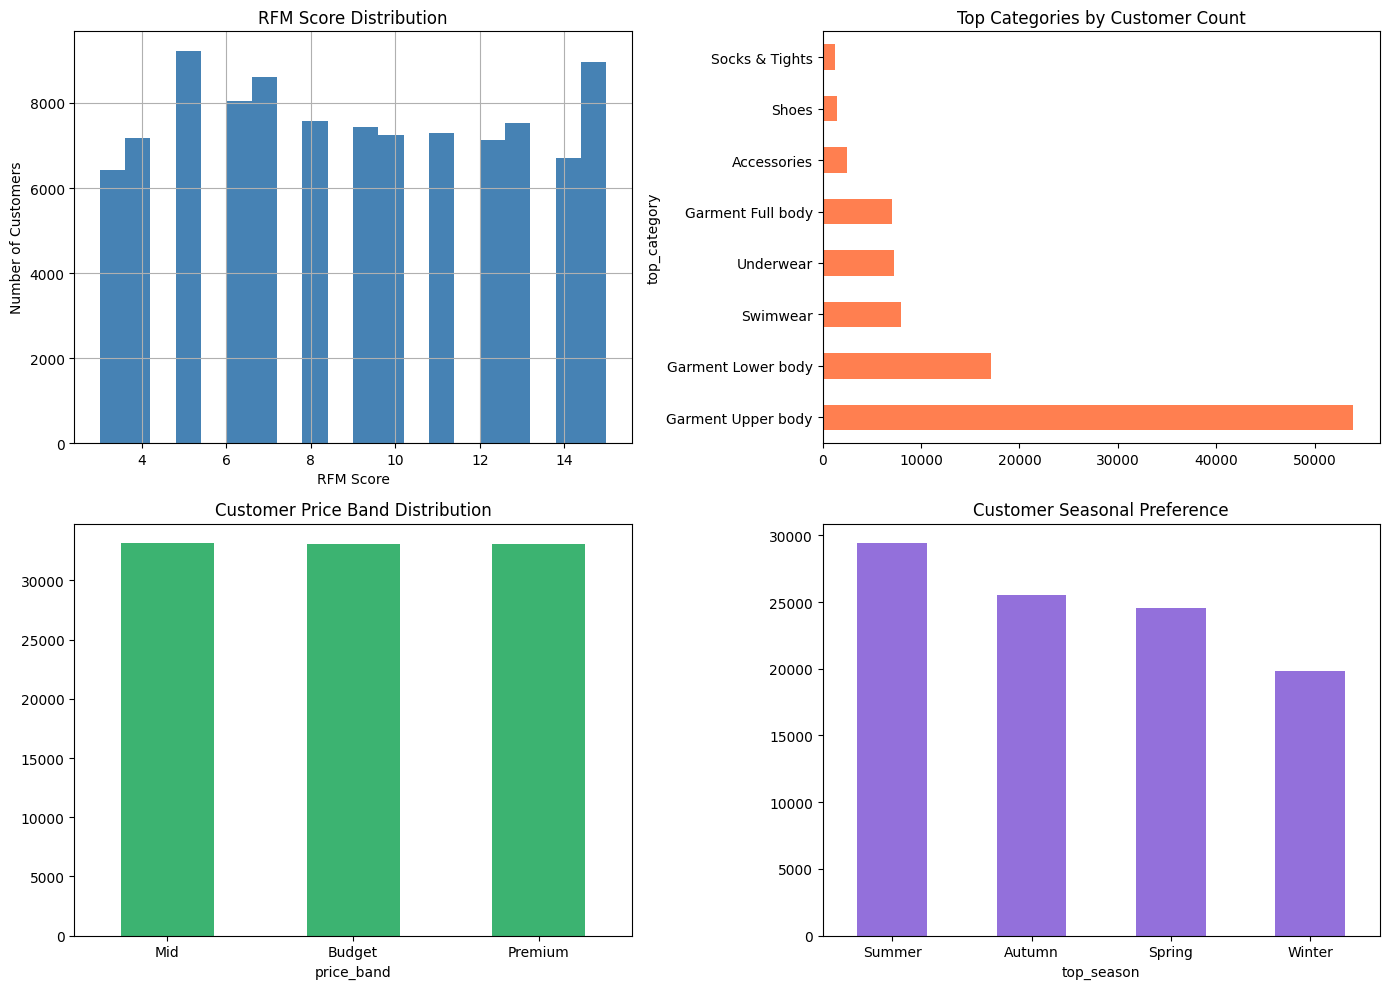

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RFM score distribution
customer_features['RFM_score'].hist(bins=20, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('RFM Score Distribution')
axes[0,0].set_xlabel('RFM Score')
axes[0,0].set_ylabel('Number of Customers')

# Top categories
top_cats = customer_features['top_category'].value_counts().head(8)
top_cats.plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Top Categories by Customer Count')

# Price band distribution
customer_features['price_band'].value_counts().plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Customer Price Band Distribution')
axes[1,0].tick_params(axis='x', rotation=0)

# Seasonal preference
customer_features['top_season'].value_counts().plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Customer Seasonal Preference')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/kaggle/working/feature_distributions.png', dpi=150)
plt.show()

In [12]:
customer_features.to_parquet('/kaggle/working/customer_features.parquet', index=False)
articles.to_parquet('/kaggle/working/articles_features.parquet', index=False)

print("Saved customer_features.parquet")
print(f"Shape: {customer_features.shape}")
print("\nSaved articles_features.parquet")
print(f"Shape: {articles.shape}")

# Final check - no customer should have null RFM scores
print(f"\nNull check on RFM columns:")
print(customer_features[['recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score']].isnull().sum())

Saved customer_features.parquet
Shape: (99345, 18)

Saved articles_features.parquet
Shape: (81940, 28)

Null check on RFM columns:
recency      0
frequency    0
monetary     0
R_score      0
F_score      0
M_score      0
dtype: int64
